In [12]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../Datasets/weight-height.csv')

In [4]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
df.shape

(10000, 3)

In [6]:
df["Height"].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

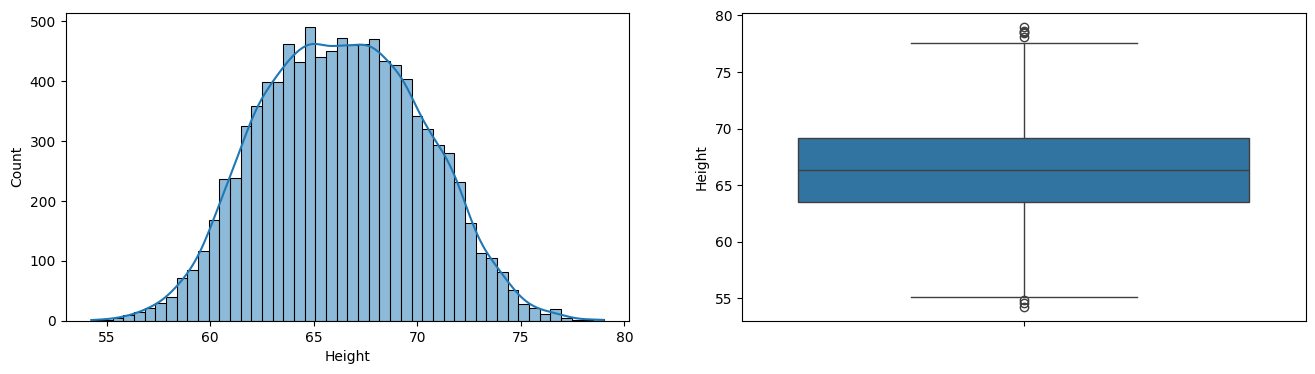

In [14]:
plt.figure(figsize=(16,4))
plt.subplot(121)
sns.histplot(df["Height"], kde=True)

plt.subplot(122)
sns.boxplot(df["Height"])

plt.show()

In [15]:
upper_limit = df["Height"].quantile(0.99)
upper_limit

74.7857900583366

In [16]:
lower_limit = df["Height"].quantile(0.01)
lower_limit

58.13441158671655

In [24]:
new_df = df[ ( df["Height"] < upper_limit ) & ( df["Height"] > lower_limit ) ]
new_df["Height"].describe()

(9800, 3)


count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64

In [25]:
print(new_df.shape)

(9800, 3)


In [19]:
df["Height"].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

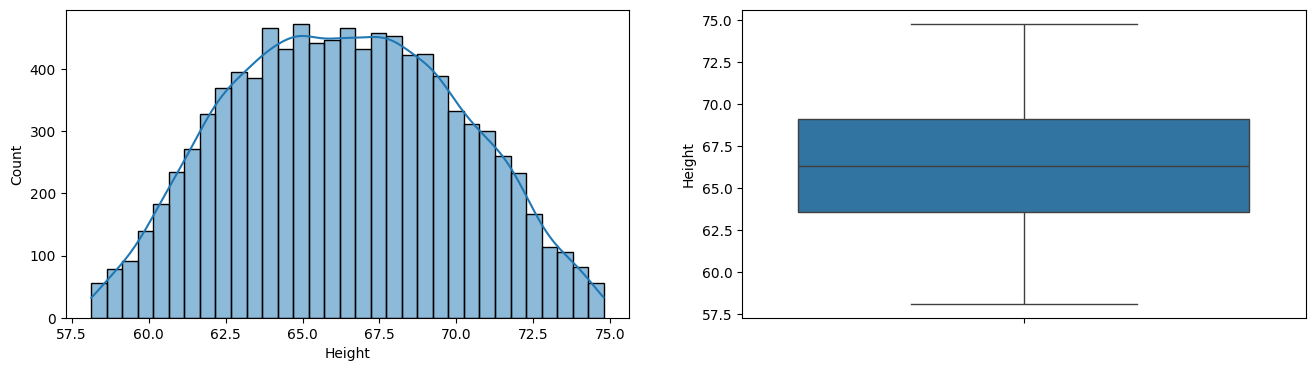

In [23]:
plt.figure(figsize=(16,4))
plt.subplot(121)
sns.histplot(new_df["Height"], kde=True)

plt.subplot(122)
sns.boxplot(new_df["Height"])

plt.show()

In [26]:
## Capping (Winsorization)
df["Height"] = np.where(df["Height"] > upper_limit,
                       upper_limit,
                       np.where(df["Height"] < lower_limit,
                               lower_limit,
                               df["Height"]
                               )
                       )
df.shape

(10000, 3)

In [27]:
df["Height"].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

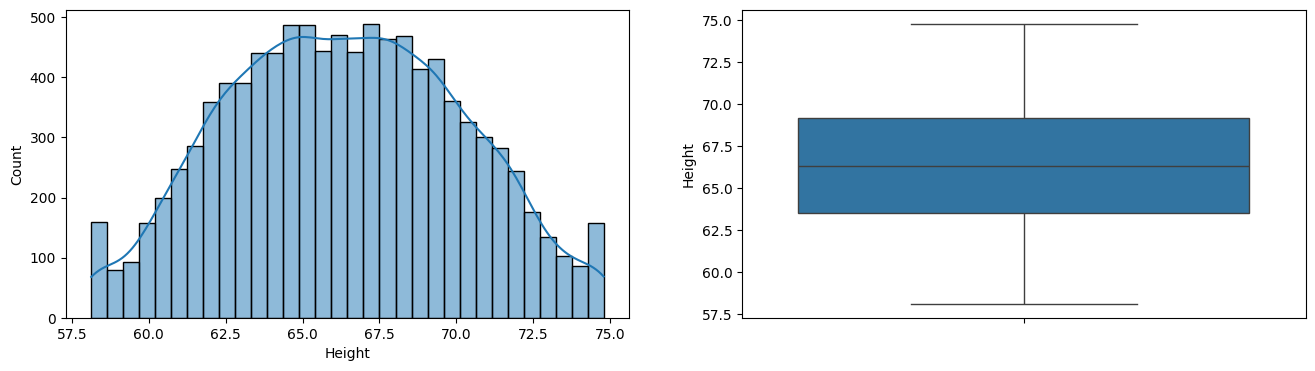

In [28]:
plt.figure(figsize=(16,4))
plt.subplot(121)
sns.histplot(df["Height"], kde=True)

plt.subplot(122)
sns.boxplot(df["Height"])

plt.show()